# FASTQ Dataset Preparation for Lupus Autoimmune Analysis

## Project Overview

This project prepares RNA sequencing datasets for bioinformatics analysis of **Systemic Lupus Erythematosus (SLE)**, an autoimmune disease.
The dataset contains sequencing reads from healthy individuals and lupus patients. The data will be used for downstream bioinformatics analysis such as read statistics, visualization, and disease-related comparisons.

The sequencing data was obtained from the public repository **NCBI Sequence Read Archive**.

---

This dataset can be used for RNA-seq analysis, read statistics, and potential disease classification tasks.

## Dataset Source

Database: **NCBI Sequence Read Archive**

Project Accession: **PRJNA379992**


Cell 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Cell 2 — Create Project Folders

In [ ]:
import os

base_path = "/content/drive/MyDrive/lupus_fastq_project"

healthy_path = f"{base_path}/healthy"
disease_path = f"{base_path}/disease"

os.makedirs(healthy_path, exist_ok=True)
os.makedirs(disease_path, exist_ok=True)

print("Project folders created:")
print(os.listdir(base_path))

Project folders created:
['healthy', 'disease']


Cell 3 — Install SRA Toolkit

In [ ]:
!apt-get update -y
!apt-get install sra-toolkit -y

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,827 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [62.6 kB]
Get

Cell 4 — Define Dataset IDs

In [ ]:
healthy_runs = [
"SRR5413733",
"SRR5413734",
"SRR5413735",
"SRR5413736",
"SRR5413737"
]

disease_runs = [
"SRR5413805",
"SRR5413806",
"SRR5413807",
"SRR5413808",
"SRR5413809"
]

print("Healthy samples:", healthy_runs)
print("Disease samples:", disease_runs)

Healthy samples: ['SRR5413733', 'SRR5413734', 'SRR5413735', 'SRR5413736', 'SRR5413737']
Disease samples: ['SRR5413805', 'SRR5413806', 'SRR5413807', 'SRR5413808', 'SRR5413809']


Cell 5 — Download Function (FULL FASTQ)

In [ ]:
def download_fastq(run_list, save_path):

    import os

    for run in run_list:

        print(f"\n========== Processing {run} ==========")

        # Download SRA file
        !prefetch {run} --output-directory {save_path}

        sra_file = f"{save_path}/{run}/{run}.sra"

        # Convert SRA → FASTQ
        !fasterq-dump {sra_file} \
            --split-files \
            --threads 4 \
            --outdir {save_path} \
            --temp /content

        print(f"{run} FASTQ conversion finished")

        # Optional: delete SRA file to save space
        !rm -rf {save_path}/{run}

        print(f"{run} cleanup done")

Cell 6 — Download Healthy Samples

In [ ]:
download_fastq(healthy_runs, healthy_path)


========== Processing SRR5413733 ==========

2026-03-10T00:14:24 prefetch.2.11.3: Current preference is set to retrieve SRA Normalized Format files with full base quality scores.
2026-03-10T00:14:24 prefetch.2.11.3: 1) Downloading 'SRR5413733'...
2026-03-10T00:14:24 prefetch.2.11.3: SRA Normalized Format file is being retrieved, if this is different from your preference, it may be due to current file availability.
2026-03-10T00:14:24 prefetch.2.11.3:  Downloading via HTTPS...
2026-03-10T00:14:24 prefetch.2.11.3:  HTTPS download succeed
2026-03-10T00:14:24 prefetch.2.11.3:  'SRR5413733' is valid
2026-03-10T00:14:24 prefetch.2.11.3: 1) 'SRR5413733' was downloaded successfully
spots read      : 76,618
reads read      : 76,618
reads written   : 76,618
SRR5413733 FASTQ conversion finished
SRR5413733 cleanup done

========== Processing SRR5413734 ==========

2026-03-10T00:14:26 prefetch.2.11.3: Current preference is set to retrieve SRA Normalized Format files with full base quality scores.


Cell 7 — Download Disease Samples

In [ ]:
download_fastq(disease_runs, disease_path)


========== Processing SRR5413805 ==========

2026-03-10T00:14:45 prefetch.2.11.3: Current preference is set to retrieve SRA Normalized Format files with full base quality scores.
2026-03-10T00:14:46 prefetch.2.11.3: 1) Downloading 'SRR5413805'...
2026-03-10T00:14:46 prefetch.2.11.3: SRA Normalized Format file is being retrieved, if this is different from your preference, it may be due to current file availability.
2026-03-10T00:14:46 prefetch.2.11.3:  Downloading via HTTPS...
2026-03-10T00:14:48 prefetch.2.11.3:  HTTPS download succeed
2026-03-10T00:14:49 prefetch.2.11.3:  'SRR5413805' is valid
2026-03-10T00:14:49 prefetch.2.11.3: 1) 'SRR5413805' was downloaded successfully
spots read      : 1,720,977
reads read      : 1,720,977
reads written   : 1,720,977
SRR5413805 FASTQ conversion finished
SRR5413805 cleanup done

========== Processing SRR5413806 ==========

2026-03-10T00:15:04 prefetch.2.11.3: Current preference is set to retrieve SRA Normalized Format files with full base quality

Cell 8 — Verify Files

In [ ]:
print("Healthy files:")
print(os.listdir(healthy_path))

print("\nDisease files:")
print(os.listdir(disease_path))

Healthy files:
['SRR5413733.fastq', 'SRR5413734.fastq', 'SRR5413735.fastq', 'SRR5413736.fastq', 'SRR5413737.fastq']

Disease files:
['SRR5413805.fastq', 'SRR5413806.fastq', 'SRR5413807.fastq', 'SRR5413808.fastq', 'SRR5413809.fastq']


Cell 9 — Download FASTQC tool

In [ ]:
!apt-get update -y
!apt-get install fastqc -y

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core default-jre default-jre-he

FASTQC folder

In [ ]:
import os

qc_path = "/content/drive/MyDrive/lupus_fastq_project/fastqc_results"
os.makedirs(qc_path, exist_ok=True)
print("FastQC results will be saved to:", qc_path)

FastQC results will be saved to: /content/drive/MyDrive/lupus_fastq_project/fastqc_results


Run FASTQC on all the samples

In [ ]:
import glob

# Healthy samples
healthy_fastq = glob.glob("/content/drive/MyDrive/lupus_fastq_project/healthy/*.fastq")

# Disease samples
disease_fastq = glob.glob("/content/drive/MyDrive/lupus_fastq_project/disease/*.fastq")

all_fastq = healthy_fastq + disease_fastq

# Run FastQC
for fq in all_fastq:
    print(f"Running FastQC on {fq} ...")
    !fastqc -o {qc_path} {fq}

Running FastQC on /content/drive/MyDrive/lupus_fastq_project/healthy/SRR5413733.fastq ...
Started analysis of SRR5413733.fastq
Approx 5% complete for SRR5413733.fastq
Approx 10% complete for SRR5413733.fastq
Approx 15% complete for SRR5413733.fastq
Approx 20% complete for SRR5413733.fastq
Approx 25% complete for SRR5413733.fastq
Approx 30% complete for SRR5413733.fastq
Approx 35% complete for SRR5413733.fastq
Approx 40% complete for SRR5413733.fastq
Approx 45% complete for SRR5413733.fastq
Approx 50% complete for SRR5413733.fastq
Approx 55% complete for SRR5413733.fastq
Approx 60% complete for SRR5413733.fastq
Approx 65% complete for SRR5413733.fastq
Approx 70% complete for SRR5413733.fastq
Approx 75% complete for SRR5413733.fastq
Approx 80% complete for SRR5413733.fastq
Approx 85% complete for SRR5413733.fastq
Approx 90% complete for SRR5413733.fastq
Approx 95% complete for SRR5413733.fastq
Analysis complete for SRR5413733.fastq
Running FastQC on /content/drive/MyDrive/lupus_fastq_pro

install biopython if not already

In [ ]:
!pip install biopython pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 27.4 MB/s eta 0:00:00


Parsing all FASTQ files and collecting stats

In [ ]:
from Bio import SeqIO
import glob
import pandas as pd
import numpy as np

# Paths to your FASTQ folders in Google Drive
healthy_fastq = glob.glob("/content/drive/MyDrive/lupus_fastq_project/healthy/*.fastq")
disease_fastq = glob.glob("/content/drive/MyDrive/lupus_fastq_project/disease/*.fastq")

all_fastq = healthy_fastq + disease_fastq

# Function to calculate GC content
def gc_content(seq):
    gc = sum(1 for b in seq if b in "GCgc")
    return gc / len(seq) * 100

# List to store statistics
stats_list = []

for fq in all_fastq:
    reads = list(SeqIO.parse(fq, "fastq"))

    num_reads = len(reads)
    mean_len = np.mean([len(r.seq) for r in reads])
    mean_qual = np.mean([np.mean(r.letter_annotations["phred_quality"]) for r in reads])
    mean_gc = np.mean([gc_content(r.seq) for r in reads])

    sample_name = fq.split("/")[-1]  # Extract filename

    stats_list.append({
        "Sample": sample_name,
        "Num_reads": num_reads,
        "Mean_length": mean_len,
        "Mean_quality": mean_qual,
        "Mean_GC%": mean_gc
    })

# Create DataFrame
df_stats = pd.DataFrame(stats_list)
df_stats

,Sample,Num_reads,Mean_length,Mean_quality,Mean_GC%
0,SRR5413733.fastq,76618,101.0,33.336091,43.861161
1,SRR5413734.fastq,98008,101.0,34.621535,46.238699
2,SRR5413735.fastq,55261,101.0,31.517867,43.045666
3,SRR5413736.fastq,39306,101.0,30.820938,44.740027
4,SRR5413737.fastq,78654,101.0,32.398566,44.684087
5,SRR5413805.fastq,1720977,101.0,36.684313,50.986343
6,SRR5413806.fastq,1764863,101.0,36.720388,50.982135
7,SRR5413807.fastq,1744750,101.0,36.729865,51.025503
8,SRR5413808.fastq,1639225,101.0,36.834486,49.977148
9,SRR5413809.fastq,1546023,101.0,36.737678,51.037379


In [ ]:
# Add Class labels
healthy_samples = [
    'SRR5413733.fastq',
    'SRR5413734.fastq',
    'SRR5413735.fastq',
    'SRR5413736.fastq',
    'SRR5413737.fastq'
]

df_stats['Class'] = df_stats['Sample'].apply(
    lambda x: 'Healthy' if x in healthy_samples else 'Disease'
)

df_stats

,Sample,Num_reads,Mean_length,Mean_quality,Mean_GC%,Class
0,SRR5413733.fastq,76618,101.0,33.336091,43.861161,Healthy
1,SRR5413734.fastq,98008,101.0,34.621535,46.238699,Healthy
2,SRR5413735.fastq,55261,101.0,31.517867,43.045666,Healthy
3,SRR5413736.fastq,39306,101.0,30.820938,44.740027,Healthy
4,SRR5413737.fastq,78654,101.0,32.398566,44.684087,Healthy
5,SRR5413805.fastq,1720977,101.0,36.684313,50.986343,Disease
6,SRR5413806.fastq,1764863,101.0,36.720388,50.982135,Disease
7,SRR5413807.fastq,1744750,101.0,36.729865,51.025503,Disease
8,SRR5413808.fastq,1639225,101.0,36.834486,49.977148,Disease
9,SRR5413809.fastq,1546023,101.0,36.737678,51.037379,Disease


Save summary table

In [ ]:
# Save summary table to Google Drive
project_path = "/content/drive/MyDrive/lupus_fastq_project"
df_stats.to_csv(f"{project_path}/fastq_summary.csv", index=False)
print("FASTQ summary saved as CSV in Drive.")

FASTQ summary saved as CSV in Drive.


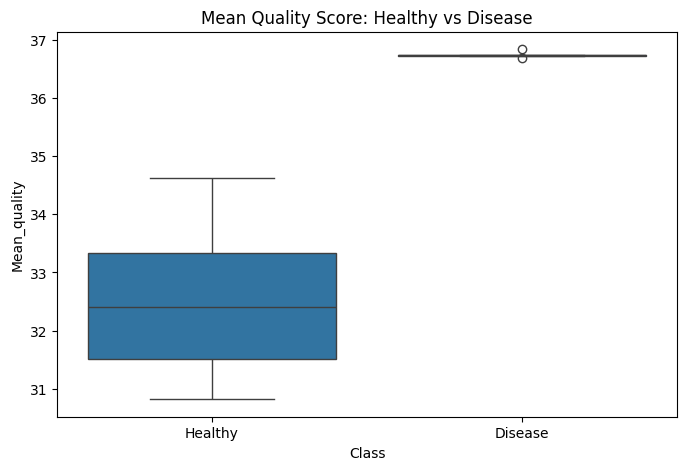

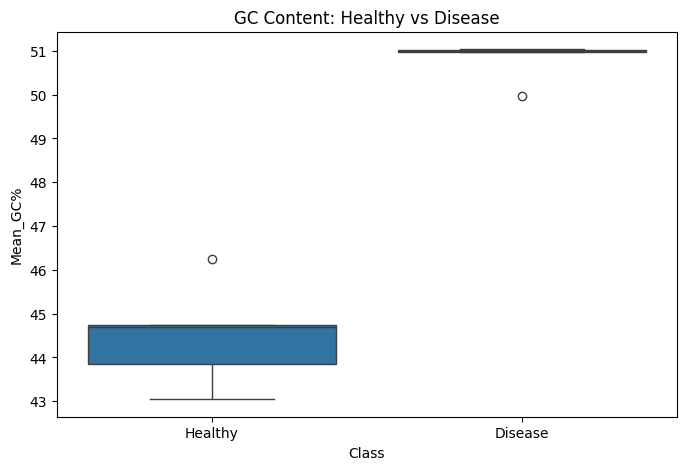

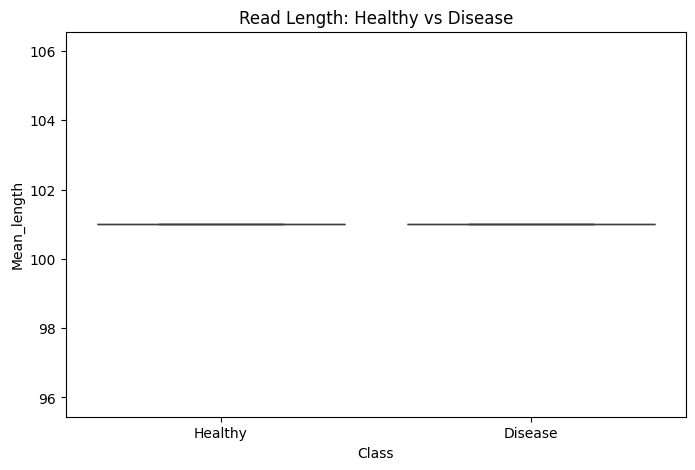

In [ ]:
# Visualize QC metrics
import seaborn as sns
import matplotlib.pyplot as plt

# Mean Quality Score
plt.figure(figsize=(8,5))
sns.boxplot(data=df_stats, x='Class', y='Mean_quality')
plt.title('Mean Quality Score: Healthy vs Disease')
plt.show()

# GC Content
plt.figure(figsize=(8,5))
sns.boxplot(data=df_stats, x='Class', y='Mean_GC%')
plt.title('GC Content: Healthy vs Disease')
plt.show()

# Mean Read Length
plt.figure(figsize=(8,5))
sns.boxplot(data=df_stats, x='Class', y='Mean_length')
plt.title('Read Length: Healthy vs Disease')
plt.show()

Plot comparison (Healthy vs Disease)

In [ ]:
from Bio import SeqIO

filtered_path = "/content/drive/MyDrive/lupus_fastq_project/filtered"
import os
os.makedirs(filtered_path, exist_ok=True)

# Quality threshold
min_avg_quality = 20  # adjust as needed

for fq in all_fastq:
    filtered_reads = []
    for record in SeqIO.parse(fq, "fastq"):
        if np.mean(record.letter_annotations["phred_quality"]) >= min_avg_quality:
            filtered_reads.append(record)
    # Save filtered FASTQ
    out_file = os.path.join(filtered_path, fq.split("/")[-1])
    SeqIO.write(filtered_reads, out_file, "fastq")